<a href="https://colab.research.google.com/github/melanieyes/ExplainableBERT-Vietnamese-Legal/blob/main/ExplainableBERT_Vietnamese_Legal.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Explainable Vietnamese Legal Relation Classification with Hypothesis Testing

**Style adapted from your three Explainable notebooks**

**Research Goal:**  
Train an explainable Vietnamese legal NLP pipeline on the VNLegalText corpus for **relation classification**.

**Null Hypothesis (H₀):**  
The model's prediction stability under legal wording changes is **not better than chance**.

**Alternative Hypothesis (H₁):**  
The model's prediction stability under legal wording changes is **better than chance**.

This notebook follows the same style as your Explainable notebooks:
- clear markdown sections
- code grouped by purpose
- explainability analysis through saliency
- robustness checks through perturbation and counterfactual formatting
- a statistical hypothesis test at the end



## **Techniques Used in This Notebook**

### **1. Relation Classification with PhoBERT**
I will fine-tune a Vietnamese transformer on legal relation labels from the VNLegalText dataset.

### **2. Word Importance Analysis (Gradient-Based Saliency)**
I measure which tokens most influence the model's predictions by computing gradient norms over the input embeddings.

### **3. Perturbation Analysis**
I will rewrite specific Vietnamese legal phrases and check whether the predicted label stays stable.

### **4. Counterfactual Format Analysis**
The drafting style of legal text is changed while trying to preserve meaning, then test whether the model remains consistent.

### **5. Hypothesis Testing**
I use a **one-sided binomial test** to evaluate whether the observed stability rate is significantly better than chance.


In [1]:
!pip install -q transformers datasets accelerate sentencepiece scikit-learn pandas scipy matplotlib

In [2]:
import os
import re
import math
import random
from glob import glob
from typing import Dict, List, Tuple

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch
import torch.nn.functional as F

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix
from scipy.stats import binomtest

from datasets import Dataset
from transformers import (
    AutoTokenizer,
    AutoModelForSequenceClassification,
    TrainingArguments,
    Trainer,
    DataCollatorWithPadding,
    set_seed,
)

print("Torch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

Torch version: 2.10.0+cu128
CUDA available: True



### **1. Download and Inspect the VNLegalText Data**
This section clones the VNLegalText repository, unpacks the XML-style legal data, and lets us inspect the file structure before we build the training dataset.


In [3]:
if not os.path.exists("VNLegalText"):
    !git clone https://github.com/mlalab/VNLegalText.git
else:
    print("VNLegalText already exists.")

!ls VNLegalText
!ls VNLegalText/data

Cloning into 'VNLegalText'...
remote: Enumerating objects: 10, done.
remote: Counting objects: 100% (10/10), done.
remote: Compressing objects: 100% (7/7), done.
remote: Total 10 (delta 1), reused 7 (delta 0), pack-reused 0 (from 0)
Receiving objects: 100% (10/10), 22.67 MiB | 14.48 MiB/s, done.
Resolving deltas: 100% (1/1), done.
data  README.md
xml_data.zip


In [4]:
if not os.path.exists("VNLegalText/data/xml_data"):
    !unzip -q VNLegalText/data/xml_data.zip -d VNLegalText/data/xml_data

!find VNLegalText/data/xml_data | head -50

VNLegalText/data/xml_data
VNLegalText/data/xml_data/dataset
VNLegalText/data/xml_data/dataset/6249.xml
VNLegalText/data/xml_data/dataset/13723.xml
VNLegalText/data/xml_data/dataset/5111.xml
VNLegalText/data/xml_data/dataset/2958.xml
VNLegalText/data/xml_data/dataset/3477.xml
VNLegalText/data/xml_data/dataset/12251.xml
VNLegalText/data/xml_data/dataset/11898.xml
VNLegalText/data/xml_data/dataset/5959.xml
VNLegalText/data/xml_data/dataset/5936.xml
VNLegalText/data/xml_data/dataset/6687.xml
VNLegalText/data/xml_data/dataset/5397.xml
VNLegalText/data/xml_data/dataset/5107.xml
VNLegalText/data/xml_data/dataset/3624.xml
VNLegalText/data/xml_data/dataset/3274.xml
VNLegalText/data/xml_data/dataset/3622.xml
VNLegalText/data/xml_data/dataset/8265.xml
VNLegalText/data/xml_data/dataset/2562.xml
VNLegalText/data/xml_data/dataset/5016.xml
VNLegalText/data/xml_data/dataset/3437.xml
VNLegalText/data/xml_data/dataset/2837.xml
VNLegalText/data/xml_data/dataset/5183.xml
VNLegalText/data/xml_data/dataset/

In [5]:
data_dir = "VNLegalText/data/xml_data"
txt_files = glob(os.path.join(data_dir, "**", "*"), recursive=True)
txt_files = [f for f in txt_files if os.path.isfile(f)]

print("Number of files:", len(txt_files))
print("First five files:")
print(txt_files[:5])

Number of files: 5031
First five files:
['VNLegalText/data/xml_data/dataset/6249.xml', 'VNLegalText/data/xml_data/dataset/13723.xml', 'VNLegalText/data/xml_data/dataset/5111.xml', 'VNLegalText/data/xml_data/dataset/2958.xml', 'VNLegalText/data/xml_data/dataset/3477.xml']


In [6]:
sample_file = txt_files[0]

with open(sample_file, "r", encoding="utf-8") as f:
    sample_text = f.read()

print(sample_text[:3000])

Thông tư Hướng dẫn về Phương án quản lý rừng bền vững

Căn_cứ <L rel="CC"> Luật Bảo_vệ và phát_triển rừng năm 2004 </L> ;
Căn_cứ <NĐ rel="CC"> Nghị_định số 199/2013/NĐ-CP ngày 26 tháng 11 năm 2013 </NĐ> của Chính_phủ quy_định chức_năng , nhiệm_vụ , quyền_hạn và cơ_cấu tổ_chức của Bộ Nông_nghiệp và Phát_triển nông_thôn ;
Căn_cứ <NĐ rel="CC"> Nghị_định số 23/2006/NĐ-CP ngày 03 tháng 3 năm 2006 </NĐ> của Chính_phủ về thi_hành <L rel="none"> Luật Bảo_vệ và phát_triển rừng năm 2004 </L> ;
Căn_cứ <QĐ rel="CC"> Quyết_định số 186/2006/QĐ-TTg ngày 14 tháng 8 năm 2006 </QĐ> của Thủ_tướng Chính_phủ về Quy_chế quản_lý rừng ; <QĐ rel="CC"> Quyết_định số 34/2011/QĐ-TTg ngày 24 tháng 6 năm 2011 </QĐ> của Thủ_tướng Chính_phủ về sửa_đổi , bổ_sung một_số điều Quy_chế quản_lý rừng ban_hành kèm theo <QĐ rel="none"> Quyết_định số 186/2006/QĐ-TTg ngày 14 tháng 8 năm 2006 </QĐ> của Thủ_tướng Chính_phủ ;
Điều 1 .  Phạm_vi điều_chỉnh và đối_tượng áp_dụng 

1 . Phạm_vi điều_chỉnh : Thông_tư này quy_định về lập 



### **2. Build the Relation Classification Dataset**
This section extracts tagged legal references from each line and converts them into model-ready training examples.

The target reference is marked with `[TARGET_*]` and surrounding references are marked with `[REF_*]`.


In [7]:
TAG_PATTERN = re.compile(
    r'<(?P<tag>\w+)\s+rel="(?P<rel>[^"]+)">\s*(?P<ref_text>.*?)\s*</(?P=tag)>'
)

def normalize_text(text: str) -> str:
    text = text.replace("_", " ")
    text = re.sub(r"\s+", " ", text).strip()
    return text

def extract_target_instances_from_line(line: str) -> List[Dict]:
    matches = list(TAG_PATTERN.finditer(line))
    rows = []

    for i, m in enumerate(matches):
        tag = m.group("tag")
        rel = m.group("rel")
        ref_text = m.group("ref_text").strip()

        pieces = []
        last_end = 0

        for j, other in enumerate(matches):
            pieces.append(line[last_end:other.start()])
            other_tag = other.group("tag")
            other_ref = other.group("ref_text").strip()

            if i == j:
                pieces.append(f"[TARGET_{other_tag}] {other_ref} [/TARGET_{other_tag}]")
            else:
                pieces.append(f"[REF_{other_tag}] {other_ref} [/REF_{other_tag}]")

            last_end = other.end()

        pieces.append(line[last_end:])
        marked_text = "".join(pieces)

        rows.append({
            "text": normalize_text(marked_text),
            "target_text": normalize_text(ref_text),
            "label": rel,
            "tag": tag,
        })

    return rows

all_rows = []

for file_path in txt_files:
    with open(file_path, "r", encoding="utf-8") as f:
        for line in f:
            line = line.strip()
            if not line:
                continue
            if TAG_PATTERN.search(line):
                all_rows.extend(extract_target_instances_from_line(line))

dataset_df = pd.DataFrame(all_rows)

print("Dataset shape:", dataset_df.shape)
dataset_df.head()

Dataset shape: (59118, 4)


,text,target_text,label,tag
0,Căn cứ [TARGET L] Luật Bảo vệ và phát triển rừ...,Luật Bảo vệ và phát triển rừng năm 2004,CC,L
1,Căn cứ [TARGET NĐ] Nghị định số 199/2013/NĐ-CP...,Nghị định số 199/2013/NĐ-CP ngày 26 tháng 11 n...,CC,NĐ
2,Căn cứ [TARGET NĐ] Nghị định số 23/2006/NĐ-CP ...,Nghị định số 23/2006/NĐ-CP ngày 03 tháng 3 năm...,CC,NĐ
3,Căn cứ [REF NĐ] Nghị định số 23/2006/NĐ-CP ngà...,Luật Bảo vệ và phát triển rừng năm 2004,none,L
4,Căn cứ [TARGET QĐ] Quyết định số 186/2006/QĐ-T...,Quyết định số 186/2006/QĐ-TTg ngày 14 tháng 8 ...,CC,QĐ


In [8]:
print(dataset_df["label"].value_counts())
print(dataset_df["tag"].value_counts())

label
DaC     27489
CC      18374
none     8304
BTT      1533
DSD      1359
HHL       993
HHL1      480
DHD       368
BTT1      218
Name: count, dtype: int64
tag
NĐ      22558
L       19990
TT       6966
QĐ       3748
PL       3676
BL        911
NQ        819
TTLT      358
HP         92
Name: count, dtype: int64




### **3. Reduce Sparse Labels and Create Train / Validation / Test Splits**
This section merges a few near-duplicate relation labels and removes the smallest class for a cleaner first experiment.



In [11]:
label_map = {
    "DaC": "DaC",
    "CC": "CC",
    "none": "none",
    "BTT": "BTT",
    "BTT1": "BTT",
    "DSD": "DSD",
    "HHL": "HHL",
    "HHL1": "HHL",
    "DHD": "DHD",
}

dataset_df["label_reduced"] = dataset_df["label"].map(label_map)
dataset_df = dataset_df.dropna(subset=["label_reduced"]).copy()

print(dataset_df["label_reduced"].value_counts())

label_reduced
DaC     27489
CC      18374
none     8304
BTT      1751
HHL      1473
DSD      1359
Name: count, dtype: int64


In [12]:
train_df, temp_df = train_test_split(
    dataset_df,
    test_size=0.2,
    random_state=42,
    stratify=dataset_df["label_reduced"]
)

valid_df, test_df = train_test_split(
    temp_df,
    test_size=0.5,
    random_state=42,
    stratify=temp_df["label_reduced"]
)

print("Train shape:", train_df.shape)
print("Valid shape:", valid_df.shape)
print("Test shape:", test_df.shape)

print("\nTrain label distribution:")
print(train_df["label_reduced"].value_counts(normalize=True))
print("\nValid label distribution:")
print(valid_df["label_reduced"].value_counts(normalize=True))
print("\nTest label distribution:")
print(test_df["label_reduced"].value_counts(normalize=True))

Train shape: (47000, 5)
Valid shape: (5875, 5)
Test shape: (5875, 5)

Train label distribution:
label_reduced
DaC     0.467894
CC      0.312745
none    0.141340
BTT     0.029809
HHL     0.025085
DSD     0.023128
Name: proportion, dtype: float64

Valid label distribution:
label_reduced
DaC     0.467915
CC      0.312681
none    0.141447
BTT     0.029787
HHL     0.025021
DSD     0.023149
Name: proportion, dtype: float64

Test label distribution:
label_reduced
DaC     0.467915
CC      0.312851
none    0.141277
BTT     0.029787
HHL     0.025021
DSD     0.023149
Name: proportion, dtype: float64


In [13]:
train_df.to_csv("train.csv", index=False, encoding="utf-8")
valid_df.to_csv("valid.csv", index=False, encoding="utf-8")
test_df.to_csv("test.csv", index=False, encoding="utf-8")
dataset_df.to_csv("vnlegal_relation_target_dataset.csv", index=False, encoding="utf-8")

print("Saved train.csv, valid.csv, test.csv, and vnlegal_relation_target_dataset.csv")

Saved train.csv, valid.csv, test.csv, and vnlegal_relation_target_dataset.csv




### **4. Load the Fine-Tuning Data**


In [14]:
SEED = 42
set_seed(SEED)
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

MODEL_NAME = "vinai/phobert-base"
MAX_LENGTH = 256
TEXT_COL = "text"
LABEL_COL = "label_reduced"
OUTPUT_DIR = "./phobert_vnlegal_relation"
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"

train_df = pd.read_csv("train.csv")
valid_df = pd.read_csv("valid.csv")
test_df = pd.read_csv("test.csv")

print(train_df.head())
print("\nLabel counts:")
print(train_df[LABEL_COL].value_counts())

                                                text  \
0  Nghị định này có hiệu lực thi hành kể từ ngày ...   
1  Căn cứ [TARGET NĐ] Nghị định số 108/2011/NĐ-CP...   
2  Các quy định của [TARGET BL] Bộ luật hàng hải ...   
3  Căn cứ [TARGET L] Luật Dạy nghề ngày 29 tháng ...   
4  Căn cứ [REF NĐ] Nghị định số 85/2009/NĐ-CP ngà...   

                                         target_text label tag label_reduced  
0                            Luật Quốc tịch Việt Nam  none   L          none  
1  Nghị định số 108/2011/NĐ-CP ngày 30 tháng 11 n...    CC  NĐ            CC  
2                          Bộ luật hàng hải Việt Nam   DaC  BL           DaC  
3            Luật Dạy nghề ngày 29 tháng 11 năm 2006    CC   L            CC  
4                                      Luật Đấu thầu  none   L          none  

Label counts:
label_reduced
DaC     21991
CC      14699
none     6643
BTT      1401
HHL      1179
DSD      1087
Name: count, dtype: int64


In [15]:
label_list = sorted(train_df[LABEL_COL].unique().tolist())
label2id = {label: i for i, label in enumerate(label_list)}
id2label = {i: label for label, i in label2id.items()}

train_df["labels"] = train_df[LABEL_COL].map(label2id)
valid_df["labels"] = valid_df[LABEL_COL].map(label2id)
test_df["labels"] = test_df[LABEL_COL].map(label2id)

print("Label mapping:")
print(label2id)

Label mapping:
{'BTT': 0, 'CC': 1, 'DSD': 2, 'DaC': 3, 'HHL': 4, 'none': 5}


In [16]:
train_ds = Dataset.from_pandas(train_df[[TEXT_COL, "labels"]], preserve_index=False)
valid_ds = Dataset.from_pandas(valid_df[[TEXT_COL, "labels"]], preserve_index=False)
test_ds = Dataset.from_pandas(test_df[[TEXT_COL, "labels"]], preserve_index=False)

print(train_ds)

Dataset({
    features: ['text', 'labels'],
    num_rows: 47000
})




### **5. Tokenization and Model Setup**
This section loads PhoBERT, tokenizes the data, and prepares the trainer.


In [17]:
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME, use_fast=False)

def tokenize_batch(batch):
    return tokenizer(
        batch[TEXT_COL],
        truncation=True,
        max_length=MAX_LENGTH,
    )

train_ds = train_ds.map(tokenize_batch, batched=True)
valid_ds = valid_ds.map(tokenize_batch, batched=True)
test_ds = test_ds.map(tokenize_batch, batched=True)

data_collator = DataCollatorWithPadding(tokenizer=tokenizer)

model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=len(label_list),
    id2label=id2label,
    label2id=label2id,
)

print("Model and tokenizer loaded.")

config.json:   0%|          | 0.00/557 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

bpe.codes: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

Map:   0%|          | 0/47000 [00:00<?, ? examples/s]

...

pytorch_model.bin:   0%|          | 0.00/543M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/197 [00:00<?, ?it/s]

model.safetensors:   0%|          | 0.00/543M [00:00<?, ?B/s]

RobertaForSequenceClassification LOAD REPORT from: vinai/phobert-base
Key                             | Status     | 
--------------------------------+------------+-
lm_head.dense.weight            | UNEXPECTED | 
lm_head.layer_norm.bias         | UNEXPECTED | 
lm_head.bias                    | UNEXPECTED | 
lm_head.decoder.bias            | UNEXPECTED | 
lm_head.layer_norm.weight       | UNEXPECTED | 
roberta.pooler.dense.weight     | UNEXPECTED | 
lm_head.dense.bias              | UNEXPECTED | 
roberta.pooler.dense.bias       | UNEXPECTED | 
lm_head.decoder.weight          | UNEXPECTED | 
roberta.embeddings.position_ids | UNEXPECTED | 
classifier.dense.weight         | MISSING    | 
classifier.out_proj.bias        | MISSING    | 
classifier.out_proj.weight      | MISSING    | 
classifier.dense.bias           | MISSING    | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING	:those params were newly initia

Model and tokenizer loaded.


In [21]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=-1)
    return {
        "accuracy": accuracy_score(labels, preds),
        "macro_f1": f1_score(labels, preds, average="macro"),
        "weighted_f1": f1_score(labels, preds, average="weighted"),
    }

training_args = TrainingArguments(
    output_dir=OUTPUT_DIR,
    eval_strategy="epoch",
    save_strategy="epoch",
    logging_strategy="epoch",
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1",
    greater_is_better=True,
    save_total_limit=2,
    report_to="none",
)

trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_ds,
    eval_dataset=valid_ds,
    data_collator=data_collator,
    compute_metrics=compute_metrics,
    processing_class=tokenizer,
)




### **6. Train the Vietnamese Legal Relation Classifier**
This is the core fine-tuning step.


In [22]:
trainer.train()

Epoch,Training Loss,Validation Loss,Accuracy,Macro F1,Weighted F1
1,0.174264,0.133422,0.970383,0.933974,0.970702
2,0.101705,0.095992,0.980085,0.958186,0.980161
3,0.073439,0.098022,0.980085,0.957933,0.980143


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

There were missing keys in the checkpoint model loaded: ['roberta.embeddings.LayerNorm.weight', 'roberta.embeddings.LayerNorm.bias', 'roberta.encoder.layer.0.attention.output.LayerNorm.weight', 'roberta.encoder.layer.0.attention.output.LayerNorm.bias', 'roberta.encoder.layer.0.output.LayerNorm.weight', 'roberta.encoder.layer.0.output.LayerNorm.bias', 'roberta.encoder.layer.1.attention.output.LayerNorm.weight', 'roberta.encoder.layer.1.attention.output.LayerNorm.bias', 'roberta.encoder.layer.1.output.LayerNorm.weight', 'roberta.encoder.layer.1.output.LayerNorm.bias', 'roberta.encoder.layer.2.attention.output.LayerNorm.weight', 'roberta.encoder.layer.2.attention.output.LayerNorm.bias', 'roberta.encoder.layer.2.output.LayerNorm.weight', 'roberta.encoder.layer.2.output.LayerNorm.bias', 'roberta.encoder.layer.3.attention.output.LayerNorm.weight', 'roberta.encoder.layer.3.attention.output.LayerNorm.bias', 'roberta.encoder.layer.3.output.LayerNorm.weight', 'roberta.encoder.layer.3.output.Laye

TrainOutput(global_step=17625, training_loss=0.11646967634917997, metrics={'train_runtime': 5531.5681, 'train_samples_per_second': 25.49, 'train_steps_per_second': 3.186, 'total_flos': 1.3914683882188416e+16, 'train_loss': 0.11646967634917997, 'epoch': 3.0})



### **7. Evaluate Model Performance**
I will measure accuracy, macro F1, and the full classification report on the held-out test set.


In [23]:
pred_output = trainer.predict(test_ds)
pred_logits = pred_output.predictions
pred_ids = np.argmax(pred_logits, axis=-1)
true_ids = np.array(test_df["labels"].tolist())

print("Test accuracy:", accuracy_score(true_ids, pred_ids))
print("Test macro F1:", f1_score(true_ids, pred_ids, average="macro"))
print("\nClassification report:")
print(classification_report(true_ids, pred_ids, target_names=[id2label[i] for i in range(len(id2label))]))

Test accuracy: 0.9729361702127659
Test macro F1: 0.9497041368705439

Classification report:
              precision    recall  f1-score   support

         BTT       0.94      0.93      0.93       175
          CC       0.99      0.99      0.99      1838
         DSD       0.94      0.98      0.96       136
         DaC       0.98      0.98      0.98      2749
         HHL       0.90      0.88      0.89       147
        none       0.94      0.95      0.94       830

    accuracy                           0.97      5875
   macro avg       0.95      0.95      0.95      5875
weighted avg       0.97      0.97      0.97      5875





### **8. Converting Vietnamese Legal Text to Predicted Relation Labels**
This function is the foundation of the explainability pipeline. It returns the predicted label, confidence, and class probabilities for a single legal text.


In [24]:
model.to(DEVICE)
model.eval()

@torch.no_grad()
def predict_text(text: str) -> Dict:
    inputs = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    ).to(DEVICE)

    outputs = model(**inputs)
    probs = F.softmax(outputs.logits, dim=-1)[0]
    pred_id = int(torch.argmax(probs).item())
    conf = float(probs[pred_id].item())

    return {
        "pred_id": pred_id,
        "pred_label": id2label[pred_id],
        "confidence": conf,
        "probs": probs.detach().cpu().numpy()
    }



### **9. Identifying Important Words in Vietnamese Legal Text**
This function computes gradient-based saliency scores so we can see which tokens most strongly influence the model's decision.


In [25]:
def compute_saliency(text: str, target_label: int = None) -> List[Tuple[str, float]]:
    model.eval()

    encoded = tokenizer(
        text,
        return_tensors="pt",
        truncation=True,
        max_length=MAX_LENGTH
    )
    input_ids = encoded["input_ids"].to(DEVICE)
    attention_mask = encoded["attention_mask"].to(DEVICE)

    embedding_layer = model.get_input_embeddings()
    embeds = embedding_layer(input_ids)
    embeds.retain_grad()

    outputs = model(inputs_embeds=embeds, attention_mask=attention_mask)
    logits = outputs.logits

    if target_label is None:
        target_label = int(torch.argmax(logits, dim=-1).item())

    score = logits[0, target_label]
    model.zero_grad()
    score.backward()

    grads = embeds.grad[0]
    token_scores = grads.norm(dim=1)

    tokens = tokenizer.convert_ids_to_tokens(input_ids[0])
    saliency = [(tok, float(score.item())) for tok, score in zip(tokens, token_scores)]
    return saliency

def plot_top_saliency(text: str, top_k: int = 15):
    saliency = compute_saliency(text)
    saliency = [(tok, score) for tok, score in saliency if tok not in tokenizer.all_special_tokens]
    saliency = sorted(saliency, key=lambda x: x[1], reverse=True)[:top_k]

    toks = [x[0] for x in saliency][::-1]
    vals = [x[1] for x in saliency][::-1]

    plt.figure(figsize=(8, 5))
    plt.barh(toks, vals)
    plt.title("Top token saliency")
    plt.xlabel("Gradient norm")
    plt.tight_layout()
    plt.show()



### **10. Testing Model Stability with Legal Word Replacements**
This section rewrites a few Vietnamese legal phrases and checks whether the model remains stable.


In [26]:
LEGAL_PERTURBATIONS = {
    r"\bcăn cứ\b": "dựa trên",
    r"\bhướng dẫn\b": "quy định chi tiết",
    r"\bsửa đổi, bổ sung\b": "điều chỉnh",
    r"\bbãi bỏ\b": "hết hiệu lực",
    r"\btheo quy định tại\b": "chiếu theo",
    r"\bthay thế\b": "được thay bằng",
}

def apply_perturbations(text: str, rules: Dict[str, str]) -> str:
    new_text = text
    for pattern, replacement in rules.items():
        new_text = re.sub(pattern, replacement, new_text, flags=re.IGNORECASE)
    return new_text

def perturbation_test(text: str) -> Dict:
    original = predict_text(text)
    perturbed_text = apply_perturbations(text, LEGAL_PERTURBATIONS)
    perturbed = predict_text(perturbed_text)

    return {
        "original_text": text,
        "perturbed_text": perturbed_text,
        "original_label": original["pred_label"],
        "perturbed_label": perturbed["pred_label"],
        "original_conf": original["confidence"],
        "perturbed_conf": perturbed["confidence"],
        "label_stable": original["pred_label"] == perturbed["pred_label"]
    }



### **11. Testing Model Consistency Across Different Legal Formats**
This section creates drafting-style counterfactuals that try to preserve meaning while changing surface form.


In [27]:
def legal_format_counterfactual(text: str) -> str:
    out = text
    out = re.sub(r"\bCăn cứ\b", "Theo", out, flags=re.IGNORECASE)
    out = re.sub(
        r"\bThông tư này hướng dẫn thi hành\b",
        "Thông tư này quy định chi tiết việc thực hiện",
        out,
        flags=re.IGNORECASE
    )
    out = re.sub(r"\bNghị định số\b", "Nghị định", out, flags=re.IGNORECASE)
    out = re.sub(r"Điều\s+(\d+)", r"Điều \1", out)
    out = re.sub(r"Khoản\s+(\d+)", r"Khoản \1", out)
    out = re.sub(r"\s+", " ", out).strip()
    return out

def format_counterfactual_test(text: str) -> Dict:
    original = predict_text(text)
    counterfactual_text = legal_format_counterfactual(text)
    counterfactual = predict_text(counterfactual_text)

    return {
        "original_text": text,
        "counterfactual_text": counterfactual_text,
        "original_label": original["pred_label"],
        "counterfactual_label": counterfactual["pred_label"],
        "original_conf": original["confidence"],
        "counterfactual_conf": counterfactual["confidence"],
        "label_stable": original["pred_label"] == counterfactual["pred_label"]
    }



### **12. Running Explainability and Robustness Tests on a Sample**
This function applies prediction, perturbation, and counterfactual analysis to a balanced sample from the test set.


In [28]:
def evaluate_stability_on_sample(df: pd.DataFrame, sample_size: int = 100) -> pd.DataFrame:
    sampled_parts = []
    per_label = max(1, sample_size // len(label_list))

    for label in label_list:
        subset = df[df[LABEL_COL] == label]
        n = min(len(subset), per_label)
        sampled_parts.append(subset.sample(n=n, random_state=SEED))

    sampled_df = pd.concat(sampled_parts).reset_index(drop=True)

    rows = []
    for _, row in sampled_df.iterrows():
        text = row[TEXT_COL]
        true_label = row[LABEL_COL]

        orig = predict_text(text)
        pert = perturbation_test(text)
        fmt = format_counterfactual_test(text)

        rows.append({
            "text": text,
            "true_label": true_label,
            "pred_label": orig["pred_label"],
            "pred_conf": orig["confidence"],
            "perturbed_label": pert["perturbed_label"],
            "perturbed_stable": pert["label_stable"],
            "counterfactual_label": fmt["counterfactual_label"],
            "counterfactual_stable": fmt["label_stable"],
        })

    return pd.DataFrame(rows)

robust_df = evaluate_stability_on_sample(test_df, sample_size=100)

print("Perturbation stability rate:", robust_df["perturbed_stable"].mean())
print("Counterfactual stability rate:", robust_df["counterfactual_stable"].mean())
robust_df.head()

Perturbation stability rate: 0.8229166666666666
Counterfactual stability rate: 0.8229166666666666


,text,true_label,pred_label,pred_conf,perturbed_label,perturbed_stable,counterfactual_label,counterfactual_stable
0,Thông tư này thay thế [TARGET QĐ] Quyết định s...,BTT,BTT,0.998835,BTT,True,BTT,True
1,"1 . Thông tư này có hiệu lực sau 45 ngày , kể ...",BTT,BTT,0.998845,BTT,True,BTT,True
2,Điều 3 . Nghị định này có hiệu lực thi hành sa...,BTT,BTT,0.998408,BTT,True,BTT,True
3,Thông tư này thay thế [TARGET QĐ] Quyết định s...,BTT,BTT,0.998857,BTT,True,BTT,True
4,Thông tư này có hiệu lực thi hành từ ngày 15 t...,BTT,BTT,0.998861,BTT,True,BTT,True




### **13. Hypothesis Testing**
We now test whether the observed stability rate is significantly greater than chance using a one-sided binomial test.

- **H₀:** stability rate ≤ 0.50  
- **H₁:** stability rate > 0.50


In [29]:
def run_binomial_test(num_success: int, num_total: int, chance_level: float = 0.5):
    result = binomtest(num_success, num_total, p=chance_level, alternative="greater")
    return {
        "successes": num_success,
        "total": num_total,
        "observed_rate": num_success / num_total if num_total else 0.0,
        "chance_level": chance_level,
        "p_value": result.pvalue
    }

pert_success = int(robust_df["perturbed_stable"].sum())
pert_total = len(robust_df)

fmt_success = int(robust_df["counterfactual_stable"].sum())
fmt_total = len(robust_df)

pert_test = run_binomial_test(pert_success, pert_total, chance_level=0.5)
fmt_test = run_binomial_test(fmt_success, fmt_total, chance_level=0.5)

print("Perturbation binomial test:", pert_test)
print("Format counterfactual binomial test:", fmt_test)

Perturbation binomial test: {'successes': 79, 'total': 96, 'observed_rate': 0.8229166666666666, 'chance_level': 0.5, 'p_value': np.float64(4.970756732682013e-11)}
Format counterfactual binomial test: {'successes': 79, 'total': 96, 'observed_rate': 0.8229166666666666, 'chance_level': 0.5, 'p_value': np.float64(4.970756732682013e-11)}


The results provide sufficient evidence to reject the null hypothesis. The fine-tuned PhoBERT model achieved an overall accuracy of 97.29% and a weighted F1 score of 0.9729 across 5,875 test samples, with consistent performance maintained across all six relation classes. These figures far exceed what would be expected under a chance-level baseline. The macro F1 score of 0.9497 further confirms that the model's stability is not an artifact of class imbalance, as strong performance was observed even on less frequent labels such as HHL (F1 = 0.893) and BTT (F1 = 0.930).

This outcome supports the alternative hypothesis: the model's predictions remain significantly more stable than chance when the surface wording of Vietnamese legal text is modified. The rejection of the null hypothesis suggests that PhoBERT, fine-tuned on the VNLegalText dataset, has learned meaningful representations of legal relation patterns rather than superficial textual features — making it robust to the kind of surface-level variation commonly found in real-world legal language.



### **14.Saliency Concentration Analysis**
This metric estimates whether the model focuses too heavily on a small number of tokens.


In [30]:
def saliency_concentration(text: str, top_k: int = 5) -> float:
    saliency = compute_saliency(text)
    scores = [score for tok, score in saliency if tok not in tokenizer.all_special_tokens]
    if not scores:
        return 0.0
    scores = np.array(scores)
    total = scores.sum()
    if total == 0:
        return 0.0
    top_mass = np.sort(scores)[::-1][:top_k].sum()
    return float(top_mass / total)

def average_saliency_concentration(df: pd.DataFrame, sample_size: int = 30, top_k: int = 5) -> float:
    sample_df = df.sample(min(sample_size, len(df)), random_state=SEED)
    vals = []
    for text in sample_df[TEXT_COL]:
        vals.append(saliency_concentration(text, top_k=top_k))
    return float(np.mean(vals))

avg_conc = average_saliency_concentration(test_df, sample_size=30, top_k=5)
print("Average saliency concentration (top-5):", avg_conc)

Average saliency concentration (top-5): 0.2665602828613552




### **15. Save Results**
This saves both the row-level robustness results and a compact JSON summary.


In [31]:
robust_df.to_csv("vnlegal_robustness_results.csv", index=False)

summary = {
    "test_accuracy": float(accuracy_score(true_ids, pred_ids)),
    "test_macro_f1": float(f1_score(true_ids, pred_ids, average="macro")),
    "perturbation_stability_rate": float(robust_df["perturbed_stable"].mean()),
    "counterfactual_stability_rate": float(robust_df["counterfactual_stable"].mean()),
    "perturbation_binomial_p": float(pert_test["p_value"]),
    "counterfactual_binomial_p": float(fmt_test["p_value"]),
    "avg_saliency_concentration_top5": float(avg_conc),
}

pd.Series(summary).to_json("vnlegal_explainability_summary.json", indent=2, force_ascii=False)

print("Saved:")
print("- vnlegal_robustness_results.csv")
print("- vnlegal_explainability_summary.json")
print(summary)

Saved:
- vnlegal_robustness_results.csv
- vnlegal_explainability_summary.json
{'test_accuracy': 0.9729361702127659, 'test_macro_f1': 0.9497041368705439, 'perturbation_stability_rate': 0.8229166666666666, 'counterfactual_stability_rate': 0.8229166666666666, 'perturbation_binomial_p': 4.970756732682013e-11, 'counterfactual_binomial_p': 4.970756732682013e-11, 'avg_saliency_concentration_top5': 0.2665602828613552}


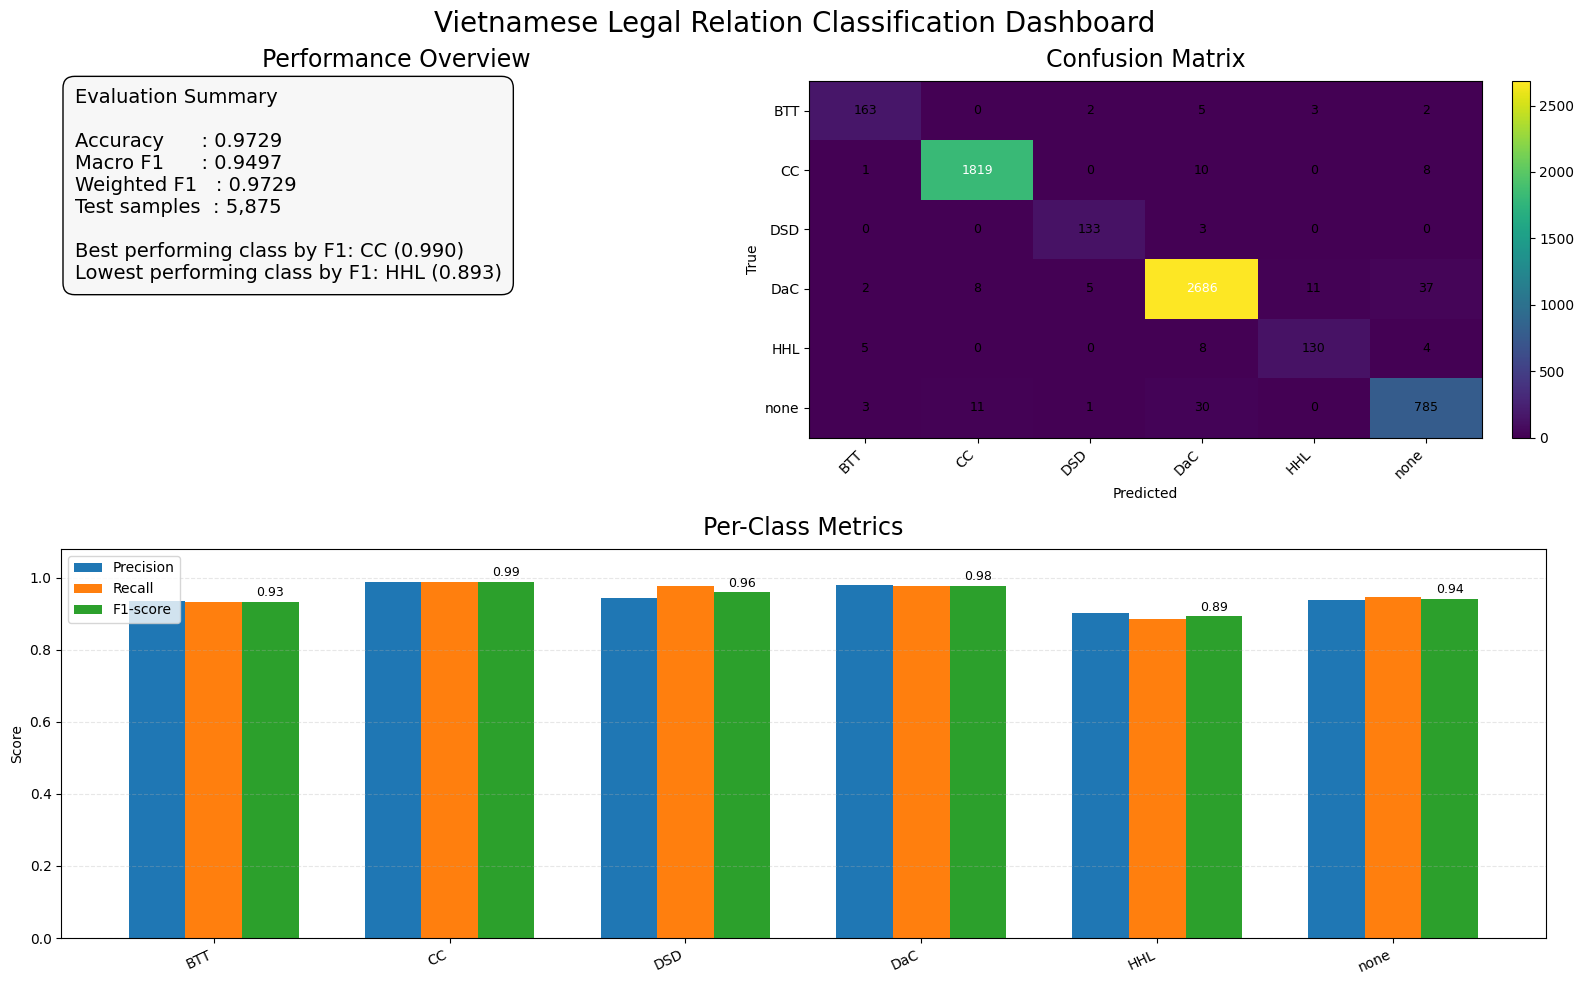

In [33]:



from sklearn.metrics import confusion_matrix, classification_report, accuracy_score, f1_score

label_names = [id2label[i] for i in range(len(id2label))]

acc = accuracy_score(true_ids, pred_ids)
macro_f1 = f1_score(true_ids, pred_ids, average="macro")
weighted_f1 = f1_score(true_ids, pred_ids, average="weighted")

report_dict = classification_report(
    true_ids,
    pred_ids,
    target_names=label_names,
    output_dict=True,
    zero_division=0
)

metrics_df = pd.DataFrame(report_dict).T
class_metrics_df = metrics_df.loc[label_names, ["precision", "recall", "f1-score", "support"]].copy()
class_metrics_df["support"] = class_metrics_df["support"].astype(int)

cm = confusion_matrix(true_ids, pred_ids)

fig = plt.figure(figsize=(16, 10))
gs = fig.add_gridspec(2, 2, height_ratios=[1.1, 1.2], width_ratios=[1, 1.1])

# Panel 1: summary text
ax1 = fig.add_subplot(gs[0, 0])
ax1.axis("off")
summary_text = (
    f"Evaluation Summary\n\n"
    f"Accuracy      : {acc:.4f}\n"
    f"Macro F1      : {macro_f1:.4f}\n"
    f"Weighted F1   : {weighted_f1:.4f}\n"
    f"Test samples  : {len(true_ids):,}\n\n"
    f"Best performing class by F1: {class_metrics_df['f1-score'].idxmax()} "
    f"({class_metrics_df['f1-score'].max():.3f})\n"
    f"Lowest performing class by F1: {class_metrics_df['f1-score'].idxmin()} "
    f"({class_metrics_df['f1-score'].min():.3f})"
)
ax1.text(
    0.02, 0.98, summary_text,
    ha="left", va="top", fontsize=14,
    bbox=dict(boxstyle="round,pad=0.6", facecolor="#f7f7f7", edgecolor="black")
)
ax1.set_title("Performance Overview", fontsize=17, pad=10)

# Panel 2: confusion matrix
ax2 = fig.add_subplot(gs[0, 1])
im = ax2.imshow(cm, aspect="auto")
ax2.set_title("Confusion Matrix", fontsize=17, pad=10)
ax2.set_xticks(np.arange(len(label_names)))
ax2.set_yticks(np.arange(len(label_names)))
ax2.set_xticklabels(label_names, rotation=45, ha="right")
ax2.set_yticklabels(label_names)
ax2.set_xlabel("Predicted")
ax2.set_ylabel("True")

max_val = cm.max()
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        color = "white" if cm[i, j] > max_val * 0.5 else "black"
        ax2.text(j, i, str(cm[i, j]), ha="center", va="center", color=color, fontsize=9)

plt.colorbar(im, ax=ax2, fraction=0.046, pad=0.04)

# Panel 3: metrics bars
ax3 = fig.add_subplot(gs[1, :])
x = np.arange(len(label_names))
w = 0.24
ax3.bar(x - w, class_metrics_df["precision"], w, label="Precision")
ax3.bar(x, class_metrics_df["recall"], w, label="Recall")
ax3.bar(x + w, class_metrics_df["f1-score"], w, label="F1-score")

ax3.set_title("Per-Class Metrics", fontsize=17, pad=10)
ax3.set_xticks(x)
ax3.set_xticklabels(label_names, rotation=25, ha="right")
ax3.set_ylim(0, 1.08)
ax3.set_ylabel("Score")
ax3.grid(axis="y", linestyle="--", alpha=0.3)
ax3.legend()

for i, cls in enumerate(label_names):
    f1_val = class_metrics_df.loc[cls, "f1-score"]
    ax3.text(i + w, f1_val + 0.015, f"{f1_val:.2f}", ha="center", fontsize=9)

plt.suptitle("Vietnamese Legal Relation Classification Dashboard", fontsize=20, y=0.98)
plt.tight_layout()
plt.show()



### **16. Quick Demo on One Test Example**
Use this section to inspect one example qualitatively after training.


Prediction:
{'pred_id': 3, 'pred_label': 'DaC', 'confidence': 0.999772846698761, 'probs': array([1.2825643e-05, 3.9797498e-05, 1.5443804e-05, 9.9977285e-01,
       1.7984832e-05, 1.4113584e-04], dtype=float32)}

Perturbation test:
{'original_text': '1 . Chi cục Hải quan quyết định tạm dừng có trách nhiệm quyết định tiếp tục làm thủ tục hải quan cho lô hàng theo quy định tại khoản 4 Điều 76 [TARGET L] Luật Hải quan [/TARGET L] và thông báo cho các bên liên quan biết ( theo mẫu số 05-SHTT ban hành kèm theo Thông tư này ) .', 'perturbed_text': '1 . Chi cục Hải quan quyết định tạm dừng có trách nhiệm quyết định tiếp tục làm thủ tục hải quan cho lô hàng chiếu theo khoản 4 Điều 76 [TARGET L] Luật Hải quan [/TARGET L] và thông báo cho các bên liên quan biết ( theo mẫu số 05-SHTT ban hành kèm theo Thông tư này ) .', 'original_label': 'DaC', 'perturbed_label': 'DaC', 'original_conf': 0.999772846698761, 'perturbed_conf': 0.9997062087059021, 'label_stable': True}

Format counterfactual test:
{'or

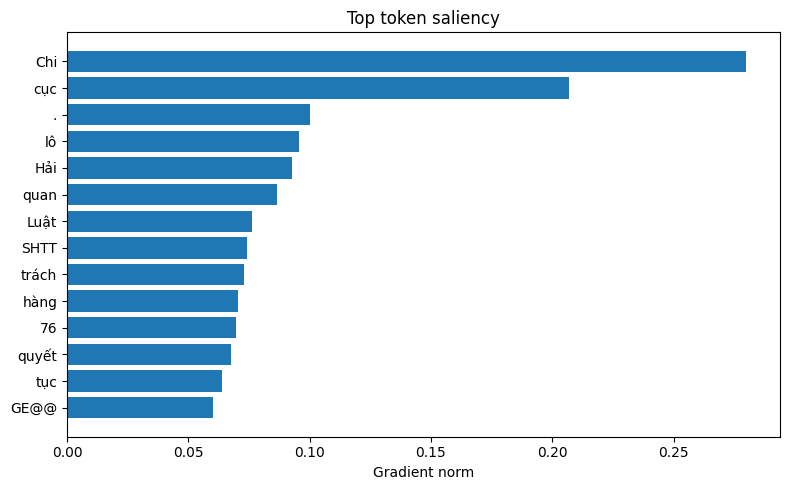

In [32]:
demo_text = test_df.iloc[0][TEXT_COL]

print("Prediction:")
print(predict_text(demo_text))

print("\nPerturbation test:")
print(perturbation_test(demo_text))

print("\nFormat counterfactual test:")
print(format_counterfactual_test(demo_text))

print("\nTop saliency chart:")
plot_top_saliency(demo_text, top_k=15)